In [1]:
import os
import pickle
import pandas as pd
import sys
from scipy.io import mmread, mmwrite
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
TISSUE_ORDER = ['LL',"RE","RW","M1","M2","Liv"]
TISSUE_COLORS = ["#6AA84F","#C27BA0","#BF4040","#6FA8DC", "#E69138","#9E9E9E"]
TISSUE_TO_COLOR = {i:j for i, j in zip(TISSUE_ORDER, TISSUE_COLORS)}
output_dir = "/data/morrisq/divyak/projects/metient/metient/jupyter_notebooks/lineage_tracing/outputs"

# CLONE=97
# CELL_OF_INT = [6]
# COMP_CELLS = [3,7,10]

CLONE=99
# CELL_OF_INT = 3
# COMP_CELLS = [0,1,2]


### Filter and save subsetted matrix file

In [2]:
# Get cell barcodes that are from clone of interest
allele_table = pd.read_csv("https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4905nnn/GSM4905334/suppl/GSM4905334_alleleTable.5k.txt.gz", sep='\t',
                           usecols = ['cellBC', 'intBC', 'r1', 'r2', 'r3', 'allele', 'LineageGroup', 'sampleID', 'readCount', 'UMI'])
cell_barcodes = allele_table[allele_table['LineageGroup']==CLONE]['cellBC'].unique()

In [3]:

# data_dir = "/data/morrisq/divyak/data/quinn_lin_tracing_2021/GSE161363"
# mtx_file = os.path.join(data_dir, "GSM4905335_matrix.5k.mtx")
# matrix = mmread(mtx_file).tocsc()  # Using a compressed sparse column format to handle large data
# desired_indices = barcodes[barcodes[0].isin(cell_barcodes)].index.tolist()
# filtered_matrix = matrix[:, desired_indices]
# mmwrite(os.path.join(data_dir, f"clone_{CLONE}_matrix.5k.mtx"), filtered_matrix)


In [4]:
# Load the MTX file
data_dir = "/data/morrisq/divyak/data/quinn_lin_tracing_2021/GSE161363"
mtx_file = os.path.join(data_dir, f"clone_{CLONE}_matrix.5k.mtx")
matrix = mmread(mtx_file).tocsc()  # Using a compressed sparse column format to handle large data

barcode_file = os.path.join(data_dir, "GSM4905335_barcodes.5k.tsv")
gene_file = os.path.join(data_dir, "GSM4905335_genes.5k.tsv")

barcodes = pd.read_csv(barcode_file, header=None, sep='\t')
genes = pd.read_csv(gene_file, header=None, sep='\t')

# Get the indices of the desired barcodes
desired_indices = barcodes[barcodes[0].isin(cell_barcodes)].index.tolist()
filtered_barcodes = barcodes.iloc[desired_indices]

In [5]:
filtered_barcodes

,0
146,LL.ACATGGTAGGAATCGC-1
498,LL.CAAGATCAGTAGCCGA-1
699,LL.CCATTCGAGGTGGGTT-1
1020,LL.CTAGCCTCAAACGCGA-1
1233,LL.GACGCGTCACGAGGTA-1
3993,RW.CGAGAAGCAGCGTCCA-1
6087,RW.TATCTCAAGTTGAGAT-1
6259,RW.TCGAGGCCAATGTTGC-1
6469,RW.TGATTTCGTGTGACCC-1
8511,RE.CATATGGTCAATCTCT-1


In [6]:
lt_dir = "/data/morrisq/divyak/projects/metient/metient/data/quinn_lt_2021/"
cass_results_dir = os.path.join(lt_dir, "cassiopeia_outputs")

with open(os.path.join(cass_results_dir,f'{CLONE}_vanilla_cas_networkx.pkl'), 'rb') as f:
    G = pickle.load(f)

In [7]:
import scanpy as sc

# Load the filtered matrix from earlier steps
adata = sc.read_mtx(os.path.join(data_dir,f'clone_{CLONE}_matrix.5k.mtx'))
adata = adata.transpose()

# Assign barcodes as observations and genes as variables
adata.obs_names = filtered_barcodes[0].values  # Assign barcodes to the cells
adata.var_names = genes[0].values     # Assign genes to the variables

# Preprocess the data
sc.pp.filter_genes(adata, min_cells=3)    # Filter genes expressed in fewer than 3 cells
# Normalize by median UMI
total_umis_per_cell = np.ravel(adata.X.sum(axis=1))  # Axis=1 sums across rows for each cell
print(total_umis_per_cell)
median_umis = np.median(total_umis_per_cell)  # Use np.median to compute the median
print(median_umis)
adata.X = adata.X / median_umis
sc.pp.log1p(adata)  # Log-transform the data


[20854. 21741. 18848. 23081. 26099.  8226.  9999. 16294. 23276.  5575.
  6192.  7895.  5139.  7242.  6896.  8690.  2477.  2928.  4022.  3281.
  5883.  4494.  4236.  5972.  6625.  4862.]
6760.5


In [8]:
cell_bc_to_tissue = {x:x.split(".")[0] for x in list(adata.obs_names)}

adata.obs['cell_tissue'] = adata.obs_names.map(cell_bc_to_tissue)
adata.obs['color'] = adata.obs['cell_tissue'].map(TISSUE_TO_COLOR)

# Annotate each cell with its number
node_to_tree_idx = {}
for i,node in enumerate(G.nodes):
    if "cassiopeia" not in node:
        node_to_tree_idx[node] = i 
tree_idx_to_node = {v:k for k,v in node_to_tree_idx.items()}

In [9]:
tree_idx_to_node

{0: 'RW.TGATTTCGTGTGACCC-1',
 1: 'RW.TCGAGGCCAATGTTGC-1',
 2: 'RW.TATCTCAAGTTGAGAT-1',
 3: 'RW.CGAGAAGCAGCGTCCA-1',
 4: 'RW.AGTGGGAGTATATCCG-1',
 5: 'RE.CATATGGTCAATCTCT-1',
 6: 'M2.TGGTTCCTCCTAAGTG-1',
 7: 'M2.GTAACTGCACACATGT-1',
 8: 'M2.GGAACTTAGCCGGTAA-1',
 9: 'M2.CTGCGGATCATACGGT-1',
 10: 'M2.CGAGAAGGTCCAGTAT-1',
 11: 'M2.CATGGCGTCGCCGTGA-1',
 12: 'M2.CACTCCAAGTCCTCCT-1',
 13: 'M2.ATCCACCAGGAGCGTT-1',
 14: 'M2.ATCATGGGTTCCTCCA-1',
 15: 'M2.AGTGGGAGTTCTCATT-1',
 16: 'M2.AAGGTTCAGTAAGTAC-1',
 17: 'M2.AACTCTTCAGGTCTCG-1',
 18: 'M1.TGGCCAGTCATGTGGT-1',
 19: 'M1.TCGCGTTCACGAGGTA-1',
 20: 'M1.TACCTTAGTCTCCACT-1',
 21: 'M1.CAGGTGCTCCTGCAGG-1',
 22: 'LL.GACGCGTCACGAGGTA-1',
 23: 'LL.CTAGCCTCAAACGCGA-1',
 24: 'LL.CCATTCGAGGTGGGTT-1',
 25: 'LL.CAAGATCAGTAGCCGA-1',
 26: 'LL.ACATGGTAGGAATCGC-1',
 43: 'primary'}

In [10]:


# Calculate cosine similarity for each cell of interest
similarity_scores = {cell:{} for cell in adata.obs_names}
for cell in adata.obs_names:
    cell_expression = adata[cell].X.toarray().flatten()  # Get the expression of the specific cell

    for tissue in TISSUE_ORDER:
        cells_in_tissue_excluding_cell_of_int = adata[(adata.obs['cell_tissue'] == tissue) & (~adata.obs_names.isin([cell]))]
        if len(cells_in_tissue_excluding_cell_of_int) == 0: continue
        group_mean = cells_in_tissue_excluding_cell_of_int.X.mean(axis=0).A1
        similarity = cosine_similarity([cell_expression], [group_mean])[0][0]
        similarity_scores[cell][tissue] = similarity
        
# Convert the results to a DataFrame for better visualization
similarity_df = pd.DataFrame(similarity_scores).T
print(similarity_df)

                             LL        RE        RW        M1        M2
LL.ACATGGTAGGAATCGC-1  0.917511  0.912230  0.972230  0.962182  0.951335
LL.CAAGATCAGTAGCCGA-1  0.961379  0.894009  0.954516  0.940293  0.933534
LL.CCATTCGAGGTGGGTT-1  0.944349  0.835537  0.907600  0.868681  0.903164
LL.CTAGCCTCAAACGCGA-1  0.974774  0.842888  0.931694  0.882979  0.910699
LL.GACGCGTCACGAGGTA-1  0.967191  0.805297  0.912043  0.862087  0.889832
RW.CGAGAAGCAGCGTCCA-1  0.945932  0.877270  0.934972  0.930967  0.946786
RW.TATCTCAAGTTGAGAT-1  0.947485  0.883760  0.966642  0.939542  0.953481
RW.TCGAGGCCAATGTTGC-1  0.968248  0.915175  0.939701  0.943438  0.959979
RW.TGATTTCGTGTGACCC-1  0.887341  0.839031  0.900824  0.907250  0.900613
RE.CATATGGTCAATCTCT-1  0.879867       NaN  0.905070  0.927002  0.928551
M1.CAGGTGCTCCTGCAGG-1  0.934380  0.862677  0.932307  0.874218  0.944885
M1.TACCTTAGTCTCCACT-1  0.873146  0.900506  0.917094  0.933583  0.928273
M1.TCGCGTTCACGAGGTA-1  0.786974  0.859246  0.855376  0.904819  0

Mean similarity (Group 1): 0.9462209924408688
Mean similarity (Group 1): 0.9164348975168263
Mean similarity (Group 1): 0.895131114024466
Mean similarity (Group 2): 0.8785339048444586
Mean similarity (Group 1): 0.8823240140982668


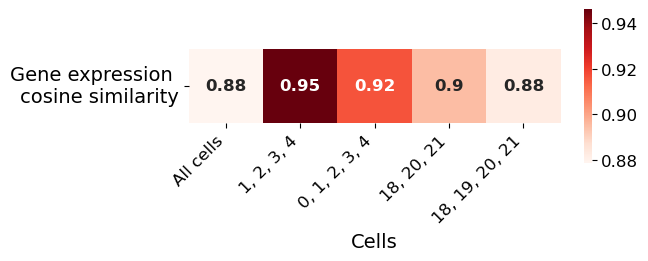

In [12]:


from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

def compare_group_similarities(adata, group1, group2):
    """
    Compare the cosine similarities within two groups of cells.

    Parameters:
    adata: AnnData object containing gene expression data.
    group1: List of identifiers for the first group of cells.
    group2: List of identifiers for the second group of cells.

    Returns:
    Dictionary with mean similarities and p-values from statistical tests.
    """
    # Extract expression data for both groups
    group1_data = adata[adata.obs_names.isin(group1)].X
    group2_data = adata[adata.obs_names.isin(group2)].X

    # Ensure both groups have more than one cell
    if group1_data.shape[0] < 2 or group2_data.shape[0] < 2:
        raise ValueError("Both groups must contain at least two cells.")
    
    # Compute pairwise cosine similarities within each group
    similarities_group1 = cosine_similarity(group1_data)
    similarities_group2 = cosine_similarity(group2_data)

    # Extract upper triangle (to avoid duplicate and self-comparisons)
    upper_triangle_group1 = similarities_group1[np.triu_indices_from(similarities_group1, k=1)]
    upper_triangle_group2 = similarities_group2[np.triu_indices_from(similarities_group2, k=1)]

    # Calculate mean similarities
    mean_group1 = np.mean(upper_triangle_group1)
    mean_group2 = np.mean(upper_triangle_group2)

    # Perform statistical tests
    t_stat, t_p_value = ttest_ind(upper_triangle_group1, upper_triangle_group2, equal_var=False)
    u_stat, mw_p_value = mannwhitneyu(upper_triangle_group1, upper_triangle_group2)

    return {
        "mean_group1": float(mean_group1),
        "mean_group2": float(mean_group2),
        "t_test_p_value": t_p_value,
        "mann_whitney_p_value": mw_p_value
    }


vector = []
labels = []

other_cells = [tree_idx_to_node[x] for x in tree_idx_to_node.keys()]

cells_of_int = [1,2,3,4]
cells_w_same_transition = [tree_idx_to_node[x] for x in cells_of_int]
result = compare_group_similarities(adata, cells_w_same_transition, other_cells)
print("Mean similarity (Group 1):", result["mean_group1"])
vector.append(result["mean_group2"])
labels.append(f"All cells")
vector.append(result["mean_group1"])
labels.append(f"{cells_of_int}")

cells_of_int = [0,1,2,3,4]
cells_w_same_transition = [tree_idx_to_node[x] for x in cells_of_int]
result = compare_group_similarities(adata, cells_w_same_transition, other_cells)
print("Mean similarity (Group 1):", result["mean_group1"])
vector.append(result["mean_group1"])
labels.append(f"{cells_of_int}")

cells_of_int = [18,20,21]
cells_w_same_transition = [tree_idx_to_node[x] for x in cells_of_int]
result = compare_group_similarities(adata, cells_w_same_transition, other_cells)
vector.append(result["mean_group1"])
print("Mean similarity (Group 1):", result["mean_group1"])
print("Mean similarity (Group 2):", result["mean_group2"])
labels.append(f"{cells_of_int}")

cells_of_int = [18,19,20,21]
cells_w_same_transition = [tree_idx_to_node[x] for x in cells_of_int]
result = compare_group_similarities(adata, cells_w_same_transition, other_cells)
print("Mean similarity (Group 1):", result["mean_group1"])
vector.append(result["mean_group1"])
labels.append(f"{cells_of_int}")

matrix = np.array(vector).reshape(1, -1)  # 1 row, automatically infer columns

# Create the heatmap
plt.figure(figsize=(6, 2))
ax = sns.heatmap(matrix, annot=True, cmap="Reds", cbar=True, square=True,xticklabels=[label.replace("[","").replace("]","") for label in labels],  
            yticklabels=['Gene expression \ncosine similarity'],annot_kws={"weight": "bold", "fontsize": 12})

# Add labels and title
plt.xlabel("Cells",fontsize=14) 
plt.xticks(rotation=45, ha='right',fontsize=12)  # Rotate labels 45 degrees and align to the right
plt.yticks(rotation=0, ha='right',fontsize=14)  # Rotate labels 45 degrees and align to the right
# Rotate the color bar (make it horizontal)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)  # Adjust tick label size of color bar


# cbar.ax.set_position([0.2, 0.01, 0.6, 0.03])  # Adjust position: [left, bottom, width, height]
# cbar.ax.xaxis.set_ticks_position('bottom')  # Place ticks below
# cbar.ax.xaxis.set_label_position('bottom')  # Place label below
plt.savefig(os.path.join(output_dir, f"{CLONE}_gene_exp_similarity.png"), dpi=500, bbox_inches='tight',pad_inches=0.1)

plt.show()